# ESConv VADER Validation

This notebook checks whether VADER sentiment scores can track how a person's emotions changed over the course of a support conversation, and compares VADER's results to the survey scores that ESConv collected from the people in those conversations.



In [20]:
%pip install datasets vaderSentiment matplotlib scipy

  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -------- ------------------------------- 1.8/8.2 MB 8.4 MB/s eta 0:00:01
   ----------------- ---------------------- 3.7/8.2 MB 8.9 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.2 MB 8.9 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.2 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 8.8 MB/s  0:00:00
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.3 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 9.2 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------- --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Load our case studies and find the ESConv ones

We load `user_case_studies.json` and pull out the IDs of the conversations that came from ESConv. Each ESConv-based case study has a `source` field that looks like `esconv_654`, so `654` is the ID we need.

In [25]:
import os
import json
from dotenv import load_dotenv
load_dotenv()

os.getenv("HF_TOKEN")


with open(r"C:\Users\Admin\OneDrive\Desktop\CBT_project\cbt-llm\data\processed\user_case_studies.json", 'r') as f:
    ucs = json.load(f)


In [26]:
esconv_ids =[int(x['source'][7:]) for x in ucs if 'esconv' in x['source']]
print(sorted(esconv_ids))

[6, 25, 27, 30, 32, 44, 46, 71, 80, 89, 94, 95, 99, 104, 114, 127, 142, 159, 163, 196, 203, 220, 223, 225, 228, 238, 250, 270, 281, 284, 300, 344, 348, 352, 367, 370, 387, 389, 429, 432, 459, 470, 517, 549, 558, 565, 574, 591, 603, 604, 616, 618, 633, 643, 654, 665, 677, 692, 714, 718, 721, 733, 747, 754, 758, 759, 777, 781, 825, 826, 828, 849, 867, 882, 890, 906]


## 2. Fetch the matching ESConv conversations

We download the full ESConv dataset from Hugging Face and grab the rows whose IDs match our case studies. Note: ESConv's row order is shifted by one compared to our IDs, so we add 1 when looking up each row.

In [ ]:
from datasets import load_dataset

ds = load_dataset("thu-coai/esconv")

esconv_train = ds["train"]
esconv_rows = {idx: json.loads(esconv_train[idx + 1]["text"]) for idx in esconv_ids}

print(f"Fetched {len(esconv_rows)} rows")
esconv_rows[esconv_ids[0]]

Fetched 76 rows


{'experience_type': 'Current Experience',
 'emotion_type': 'disgust',
 'problem_type': 'problems with friends',
 'situation': "My friend's are Trump supporters. It hurts because it does not follow my values and morals.",
 'survey_score': {'seeker': {'initial_emotion_intensity': '4',
   'empathy': '5',
   'relevance': '5',
   'final_emotion_intensity': '2'},
  'supporter': {'relevance': '5'}},
 'dialog': [{'text': 'Hello, how are you doing today?',
   'speaker': 'sys',
   'strategy': 'Others'},
  {'text': "I am OK but I have been struggling since my friend's are Trump supporters and that goes against my Morals.",
   'speaker': 'usr'},
  {'text': "I understand how your friend's supporting Trump is against your morals. Have you talked to them about it?",
   'speaker': 'sys',
   'strategy': 'Restatement or Paraphrasing'},
  {'text': 'Yes. They refuse to change.', 'speaker': 'usr'},
  {'text': "I've been in a similar situation and have dealt with friend's that support values that I don't.",

## 3. Pull out the seeker's messages

Each ESConv conversation is a back-and-forth between a "seeker" (the person asking for support) and a "supporter". We only care about the seeker's messages, so we flatten each conversation into one row per seeker turn, keeping track of which conversation and turn number each message belongs to.

In [28]:
import pandas as pd

def extract_seeker_turns(esconv_id, convo):
    """Pull the seeker ('usr') turns out of an ESConv dialog into flat rows."""
    rows = []
    usr_turn = 0
    for item in convo["dialog"]:
        if item.get("speaker") != "usr":
            continue
        usr_turn += 1
        rows.append({
            "esconv_id": esconv_id,
            "turn": usr_turn,
            "text": item["text"],
            "emotion_type": convo.get("emotion_type"),
            "problem_type": convo.get("problem_type"),
            "situation": convo.get("situation"),
        })
    return rows


all_rows = []
for esconv_id, convo in esconv_rows.items():
    all_rows.extend(extract_seeker_turns(esconv_id, convo))

esconv_df = pd.DataFrame(all_rows)
print(f"{esconv_df['esconv_id'].nunique()} conversations, {len(esconv_df)} seeker turns")
esconv_df.head()

76 conversations, 1206 seeker turns


,esconv_id,turn,text,emotion_type,problem_type,situation
0,654,1,I am OK but I have been struggling since my fr...,disgust,problems with friends,My friend's are Trump supporters. It hurts bec...
1,654,2,Yes. They refuse to change.,disgust,problems with friends,My friend's are Trump supporters. It hurts bec...
2,654,3,How did you deal with it?,disgust,problems with friends,My friend's are Trump supporters. It hurts bec...
3,654,4,Yeah I have cut out some friends already. Mayb...,disgust,problems with friends,My friend's are Trump supporters. It hurts bec...
4,654,5,Thank you for the support. It will help me.,disgust,problems with friends,My friend's are Trump supporters. It hurts bec...


## 4. Run VADER on each seeker message

VADER gives each piece of text a "compound" sentiment score from -1 (very negative) to +1 (very positive). We score every seeker turn, then also compute a running average ("cumulative sentiment") across the conversation so far.

In [29]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

esconv_df["sentiment"] = esconv_df["text"].apply(
    lambda t: analyzer.polarity_scores(t)["compound"]
)

esconv_df = esconv_df.sort_values(["esconv_id", "turn"]).reset_index(drop=True)
esconv_df["cumulative_sentiment"] = (
    esconv_df.groupby("esconv_id")["sentiment"]
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
)

esconv_df.head()

,esconv_id,turn,text,emotion_type,problem_type,situation,sentiment,cumulative_sentiment
0,6,1,Hi..Iam doing good..how are you,anxiety,academic pressure,Iam facing a lot of academic pressure to cople...,0.00,0.000000
1,6,2,Iam in final year of university and iam unable...,anxiety,academic pressure,Iam facing a lot of academic pressure to cople...,0.00,0.000000
2,6,3,Iam a mother of 2 year old son and he is givin...,anxiety,academic pressure,Iam facing a lot of academic pressure to cople...,0.25,0.083333
3,6,4,My husband is having full time job and he has ...,anxiety,academic pressure,Iam facing a lot of academic pressure to cople...,0.00,0.062500
4,6,5,My parents live in another country and they ca...,anxiety,academic pressure,Iam facing a lot of academic pressure to cople...,0.00,0.050000


## 5. Summarize each conversation

Collapse the turn-by-turn scores into one row per conversation: average sentiment, number of seeker turns, and the final cumulative sentiment (the running average at the last turn).

In [ ]:
esconv_summary = esconv_df.groupby("esconv_id", as_index=False).agg(
    avg_sentiment=("sentiment", "mean"),
    num_turns=("turn", "max"),
)

final_cum = (
    esconv_df.sort_values(["esconv_id", "turn"])
    .groupby("esconv_id", as_index=False)
    .tail(1)[["esconv_id", "cumulative_sentiment"]]
    .rename(columns={"cumulative_sentiment": "final_cumulative_sentiment"})
)

esconv_summary = esconv_summary.merge(final_cum, on="esconv_id", how="left")
esconv_summary = esconv_summary.sort_values("esconv_id").reset_index(drop=True)
esconv_summary

,esconv_id,avg_sentiment,num_turns,final_cumulative_sentiment
0,6,0.129650,10,0.129650
1,25,0.176113,16,0.176113
2,27,0.432030,10,0.432030
3,30,0.074208,13,0.074208
4,32,0.156392,12,0.156392
...,...,...,...,...
71,849,0.363536,14,0.363536
72,867,-0.148168,19,-0.148168
73,882,0.201690,10,0.201690
74,890,0.294867,18,0.294867


## 6. Bring in ESConv's own survey scores

Besides the conversation text, ESConv also asked each seeker to rate how intense their emotion felt **before** and **after** the conversation, on a 1-5 scale (`initial_emotion_intensity` and `final_emotion_intensity`).

We add these to our summary and compute two "improvement" scores:
- **`human_improvement`**: how much better the seeker said they felt (`initial - final`)
- **`vader_improvement`**: how much more positive VADER's score got, from the seeker's first message to their last

In [ ]:
survey_rows = []
for esconv_id, convo in esconv_rows.items():
    seeker_survey = convo.get("survey_score", {}).get("seeker", {})
    survey_rows.append({
        "esconv_id": esconv_id,
        "initial_emotion_intensity": float(seeker_survey.get("initial_emotion_intensity", "nan")),
        "final_emotion_intensity": float(seeker_survey.get("final_emotion_intensity", "nan")),
    })

survey_df = pd.DataFrame(survey_rows)
esconv_summary = esconv_summary.merge(survey_df, on="esconv_id", how="left")

first_last = (
    esconv_df.sort_values(["esconv_id", "turn"])
    .groupby("esconv_id")
    .agg(
        vader_initial_sentiment=("sentiment", "first"),
        vader_final_sentiment=("sentiment", "last"),
    )
    .reset_index()
)
esconv_summary = esconv_summary.merge(first_last, on="esconv_id", how="left")

esconv_summary["human_improvement"] = (
    esconv_summary["initial_emotion_intensity"] - esconv_summary["final_emotion_intensity"]
)
esconv_summary["vader_improvement"] = (
    esconv_summary["vader_final_sentiment"] - esconv_summary["vader_initial_sentiment"]
)

esconv_summary

,esconv_id,avg_sentiment,num_turns,final_cumulative_sentiment,initial_emotion_intensity,final_emotion_intensity,vader_initial_sentiment,vader_final_sentiment,human_improvement,vader_improvement
0,6,0.129650,10,0.129650,5.0,4.0,0.0000,0.6808,1.0,0.6808
1,25,0.176113,16,0.176113,4.0,1.0,0.0000,0.4926,3.0,0.4926
2,27,0.432030,10,0.432030,3.0,1.0,0.0772,0.8612,2.0,0.7840
3,30,0.074208,13,0.074208,3.0,1.0,0.2263,0.5707,2.0,0.3444
4,32,0.156392,12,0.156392,3.0,2.0,0.0000,0.5707,1.0,0.5707
...,...,...,...,...,...,...,...,...,...,...
71,849,0.363536,14,0.363536,4.0,3.0,0.0000,0.3382,1.0,0.3382
72,867,-0.148168,19,-0.148168,4.0,2.0,0.0000,0.4215,2.0,0.4215
73,882,0.201690,10,0.201690,4.0,1.0,0.0000,0.9739,3.0,0.9739
74,890,0.294867,18,0.294867,4.0,3.0,0.2280,0.6696,1.0,0.4416


## 7. Compare human vs. VADER improvement

Check the correlation between `human_improvement` and `vader_improvement`, and plot them against each other to see if VADER's view of "improvement" lines up with what people actually reported.

**Result:** the correlation is very weak, and the scatter plot shows almost no trend - VADER's last-message-vs-first-message score looks similar regardless of whether the person reported a small (1) or large (4) improvement. This is likely because conversations almost always end with the seeker thanking the supporter ("thanks, this helped!"), which is positive in tone no matter how much their underlying emotion actually changed.

Pearson r:  0.137
Spearman r: 0.067


<Axes: title={'center': 'Self-reported emotion improvement vs. VADER sentiment improvement'}, xlabel='human_improvement', ylabel='vader_improvement'>

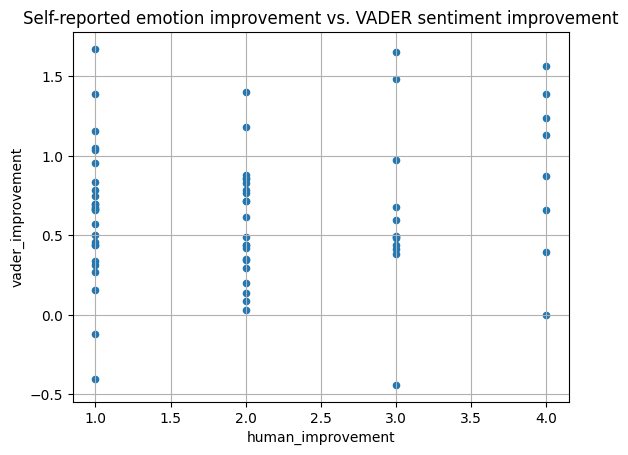

In [ ]:
import matplotlib  
pearson = esconv_summary[["human_improvement", "vader_improvement"]].corr(method="pearson").iloc[0, 1]
spearman = esconv_summary[["human_improvement", "vader_improvement"]].corr(method="spearman").iloc[0, 1]

print(f"Pearson r:  {pearson:.3f}")
print(f"Spearman r: {spearman:.3f}")

esconv_summary.plot.scatter(
    x="human_improvement",
    y="vader_improvement",
    title="Self-reported emotion improvement vs. VADER sentiment improvement",
    grid=True,
)

## 8. Try other ways of measuring VADER "improvement"

The last-message-vs-first-message score can be noisy - a single polite goodbye can swing it a lot. Here we try three more ways of summarizing each conversation's sentiment trajectory into one number:

- **`cumulative_improvement`**: the cumulative (running average) sentiment at the end vs. the seeker's first message
- **`half_split_diff`**: average sentiment of the second half of the conversation minus the first half
- **`sentiment_slope`**: the overall trend (slope) of sentiment across all of the seeker's turns

**How `sentiment_slope` is calculated:** for each conversation, we have a list of (turn number, sentiment score) points - one per seeker message. We fit a straight line through these points (using `np.polyfit`, i.e. ordinary least-squares linear regression) and take its **slope**.

- A positive slope means sentiment tends to rise as the conversation goes on (the line trends upward).
- A negative slope means sentiment tends to fall.
- A slope near zero means sentiment stays flat on average, even if individual turns bounce around.

Because the slope is fit across *every* turn rather than just the first and last, a single unusually positive or negative message has much less effect on it than on `vader_improvement` (last - first).

In [ ]:
import numpy as np

def half_split_diff(group):
    """second-half avg sentiment minus first-half avg sentiment"""
    s = group.sort_values("turn")["sentiment"].to_numpy()
    if len(s) < 2:
        return np.nan
    first_half, second_half = np.array_split(s, 2)
    return second_half.mean() - first_half.mean()

def sentiment_slope(group):
    """slope of a linear fit of sentiment over turn index"""
    g = group.sort_values("turn")
    if len(g) < 2:
        return np.nan
    return np.polyfit(g["turn"], g["sentiment"], 1)[0]

half_split = esconv_df.groupby("esconv_id").apply(half_split_diff).rename("half_split_diff")
slope = esconv_df.groupby("esconv_id").apply(sentiment_slope).rename("sentiment_slope")

esconv_summary = esconv_summary.merge(half_split.reset_index(), on="esconv_id", how="left")
esconv_summary = esconv_summary.merge(slope.reset_index(), on="esconv_id", how="left")

esconv_summary["cumulative_improvement"] = (
    esconv_summary["final_cumulative_sentiment"] - esconv_summary["vader_initial_sentiment"]
)

esconv_summary

,esconv_id,avg_sentiment,num_turns,final_cumulative_sentiment,initial_emotion_intensity,final_emotion_intensity,vader_initial_sentiment,vader_final_sentiment,human_improvement,vader_improvement,half_split_diff,sentiment_slope,cumulative_improvement
0,6,0.129650,10,0.129650,5.0,4.0,0.0000,0.6808,1.0,0.6808,0.159300,0.052639,0.129650
1,25,0.176113,16,0.176113,4.0,1.0,0.0000,0.4926,3.0,0.4926,0.251400,0.038730,0.176113
2,27,0.432030,10,0.432030,3.0,1.0,0.0772,0.8612,2.0,0.7840,0.496500,0.102121,0.354830
3,30,0.074208,13,0.074208,3.0,1.0,0.2263,0.5707,2.0,0.3444,0.025274,0.000695,-0.152092
4,32,0.156392,12,0.156392,3.0,2.0,0.0000,0.5707,1.0,0.5707,0.394317,0.069084,0.156392
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,849,0.363536,14,0.363536,4.0,3.0,0.0000,0.3382,1.0,0.3382,0.228014,0.050519,0.363536
72,867,-0.148168,19,-0.148168,4.0,2.0,0.0000,0.4215,2.0,0.4215,0.152869,0.021112,-0.148168
73,882,0.201690,10,0.201690,4.0,1.0,0.0000,0.9739,3.0,0.9739,0.888100,0.136595,0.201690
74,890,0.294867,18,0.294867,4.0,3.0,0.2280,0.6696,1.0,0.4416,0.185089,0.028322,0.066867


## 9. Compare all the candidate metrics

For each candidate VADER "improvement" metric, compute its correlation with ESConv's `human_improvement` and rank them from best to worst.

In [ ]:
candidates = {
    "last_minus_first": "vader_improvement",
    "cumulative_minus_first": "cumulative_improvement",
    "second_half_minus_first_half": "half_split_diff",
    "sentiment_trend_slope": "sentiment_slope",
}

results = []
for label, col in candidates.items():
    sub = esconv_summary[["human_improvement", col]].dropna()
    results.append({
        "metric": label,
        "pearson_r": sub["human_improvement"].corr(sub[col], method="pearson"),
        "spearman_r": sub["human_improvement"].corr(sub[col], method="spearman"),
        "n": len(sub),
    })

comparison_df = pd.DataFrame(results).sort_values("pearson_r", ascending=False).reset_index(drop=True)
comparison_df

,metric,pearson_r,spearman_r,n
0,sentiment_trend_slope,0.158030,0.155312,68
1,second_half_minus_first_half,0.142614,0.119285,68
2,last_minus_first,0.137297,0.067061,68
3,cumulative_minus_first,0.132166,0.034460,68


## Results

Across 68 conversations with enough seeker turns, all four VADER-based "improvement" metrics correlate only **weakly** with ESConv's self-reported emotion-intensity change (Pearson r between 0.13 and 0.16). `sentiment_trend_slope` (the overall trend across the whole conversation) does slightly best, but none of them are strong.

**Why the correlation is weak:** ESConv's survey measures emotion **intensity** (how strong a feeling is), while VADER measures **valence** (how positive or negative the wording is). Someone can go from "extremely anxious" to "a little anxious" - a big improvement in intensity - while both messages still sound negative to VADER. Likewise, a polite "thanks, this helped!" near the end of almost every conversation makes VADER look positive regardless of how much the person's emotions actually changed.

**Takeaway:** VADER sentiment trajectories are not a strong stand-in for ESConv's emotion-intensity ratings. They're measuring related but different things, so a low correlation here doesn't necessarily mean our VADER pipeline is wrong - it's a sign that VADER and ESConv's survey are capturing different aspects of how someone feels.